In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set professional aesthetics
plt.style.use('fivethirtyeight')
sns.set_context("talk")
sns.set_palette("husl")

# Load the Karachi data
df = pd.read_csv('karachi_schema_data.csv')

# Ensure timestamp is recognized correctly
df['datetime'] = pd.to_datetime(df['timestamp_unix'], unit='s')

print(f"Dataset ready with {df.shape[0]} rows and {df.shape[1]} features.")
df.head()

Dataset ready with 8760 rows and 20 features.


,timestamp_unix,year,month,day,hour,weekday,pm25,pm10,no2,so2,co,o3,temperature,humidity,pressure,wind_speed,dew_point,aqi,aqi_change_rate,datetime
0,1737676800,2025,1,24,0,4,13.0,14.9,19.9,8.0,524.0,70.0,18.5,25,1016.6,11.9,-2.0,52.892704,0.000000,2025-01-24 00:00:00
1,1737680400,2025,1,24,1,4,10.7,13.3,14.7,6.6,403.0,76.0,18.1,24,1015.9,12.2,-2.6,44.583333,-8.309371,2025-01-24 01:00:00
2,1737684000,2025,1,24,2,4,9.4,12.9,10.6,5.7,315.0,80.0,17.8,25,1016.0,11.1,-2.8,39.166667,-5.416667,2025-01-24 02:00:00
3,1737687600,2025,1,24,3,4,8.8,13.1,7.7,5.6,254.0,82.0,17.2,26,1015.7,11.6,-2.5,36.666667,-2.500000,2025-01-24 03:00:00
4,1737691200,2025,1,24,4,4,8.8,13.6,6.0,5.9,226.0,83.0,16.4,29,1015.7,11.3,-1.9,36.666667,0.000000,2025-01-24 04:00:00


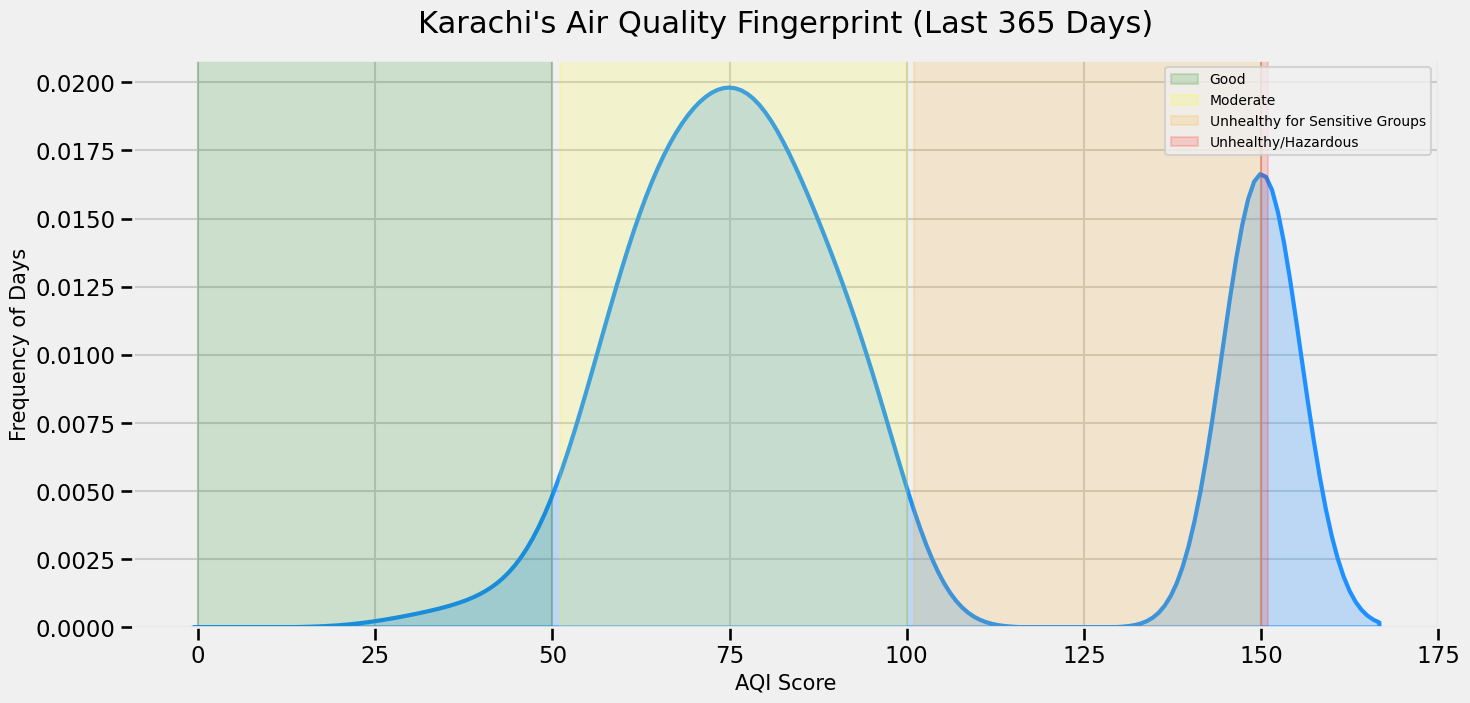

In [3]:
plt.figure(figsize=(15, 7))

# Plotting the KDE (Kernel Density Estimate)
sns.kdeplot(df['aqi'], fill=True, color="dodgerblue", lw=3)

# Adding Health Zone Backgrounds
plt.axvspan(0, 50, color='green', alpha=0.15, label='Good')
plt.axvspan(51, 100, color='yellow', alpha=0.15, label='Moderate')
plt.axvspan(101, 150, color='orange', alpha=0.15, label='Unhealthy for Sensitive Groups')
plt.axvspan(151, df['aqi'].max(), color='red', alpha=0.15, label='Unhealthy/Hazardous')

plt.title("Karachi's Air Quality Fingerprint (Last 365 Days)", fontsize=22, pad=20)
plt.xlabel("AQI Score", fontsize=15)
plt.ylabel("Frequency of Days", fontsize=15)
plt.legend(loc='upper right', fontsize=10)
plt.show()

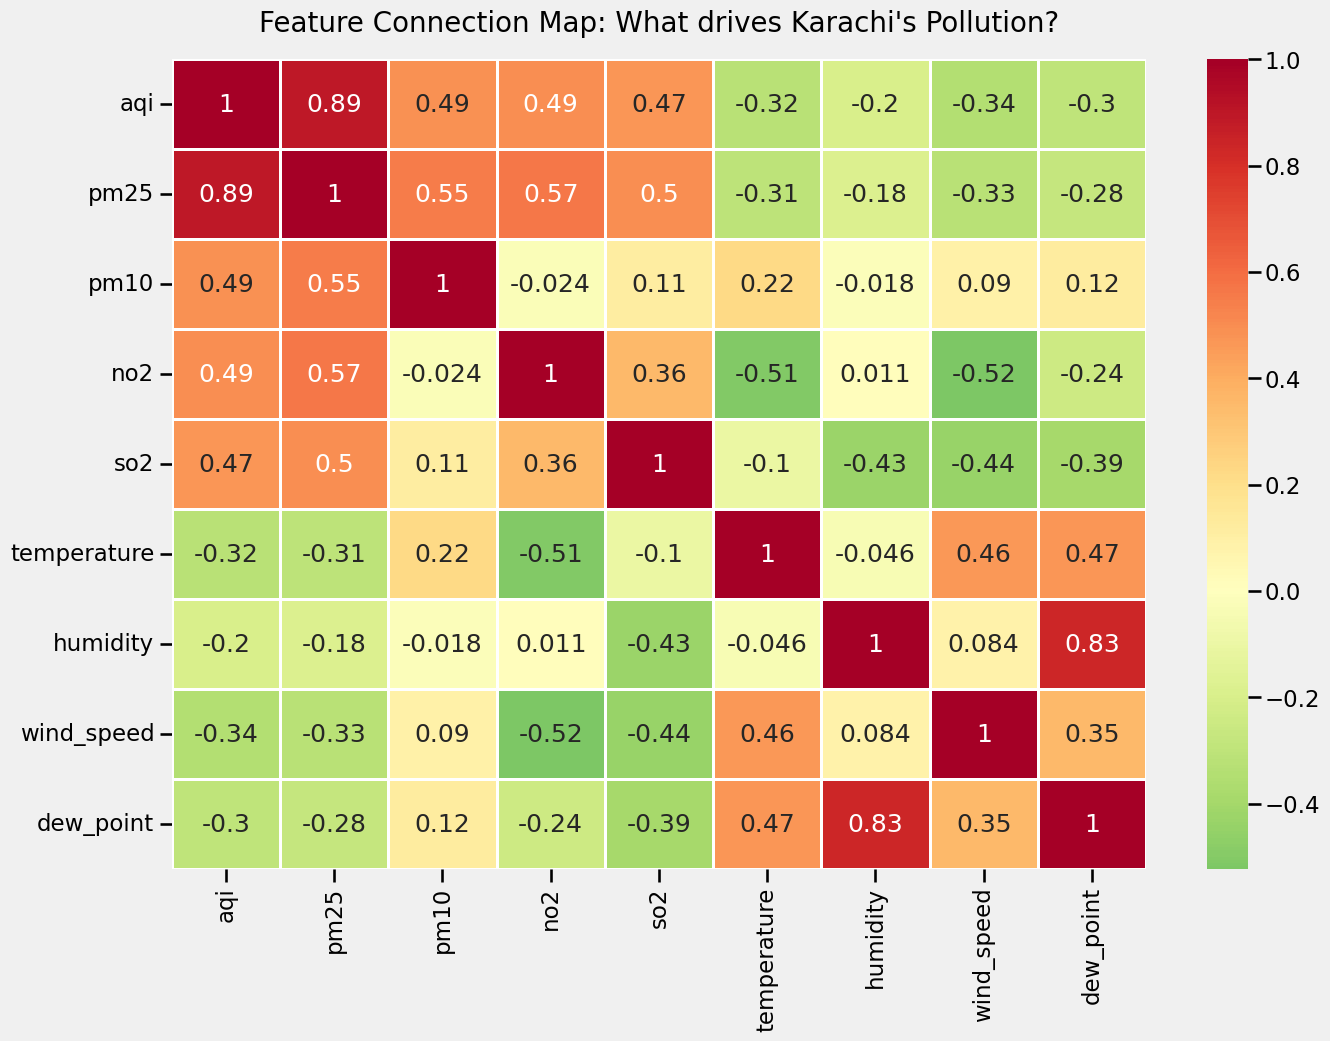

In [3]:
plt.figure(figsize=(14, 10))

# Selecting the most relevant features for the heatmap
core_features = ['aqi', 'pm25', 'pm10', 'no2', 'so2', 'temperature', 'humidity', 'wind_speed', 'dew_point']
corr_matrix = df[core_features].corr()

# Drawing the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn_r', center=0, linewidths=1, linecolor='white')
plt.title("Feature Connection Map: What drives Karachi's Pollution?", fontsize=20, pad=20)
plt.show()

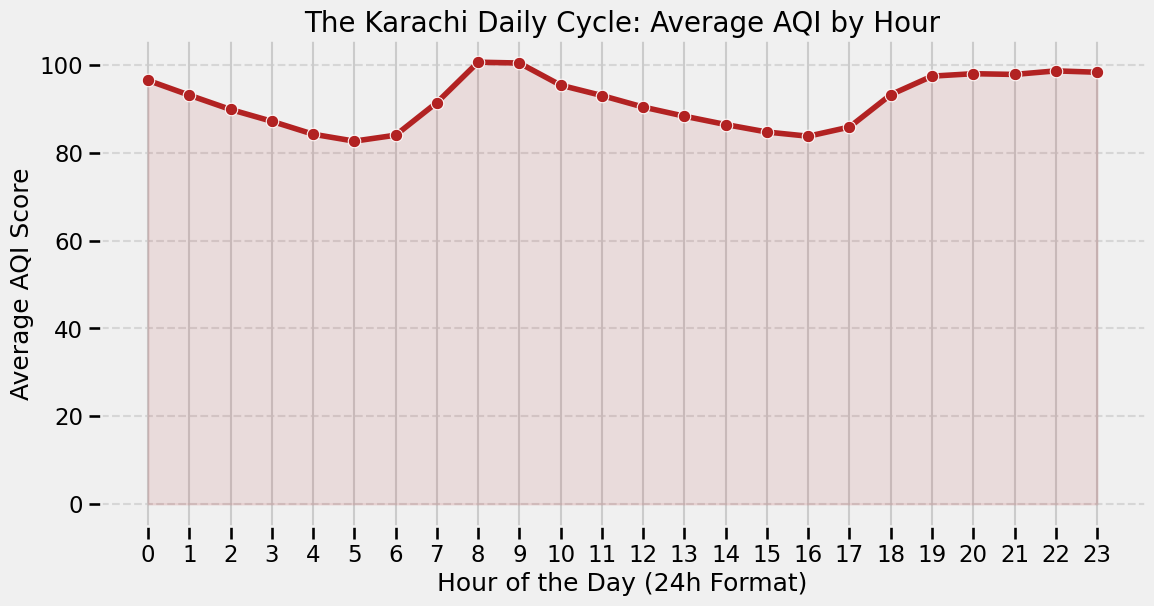

In [4]:
# Aggregate average AQI by hour
hourly_avg = df.groupby('hour')['aqi'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_avg, x='hour', y='aqi', marker='o', color='firebrick', lw=4)
plt.fill_between(hourly_avg['hour'], hourly_avg['aqi'], color="firebrick", alpha=0.1)

plt.title("The Karachi Daily Cycle: Average AQI by Hour", fontsize=20)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel("Hour of the Day (24h Format)")
plt.ylabel("Average AQI Score")
plt.show()

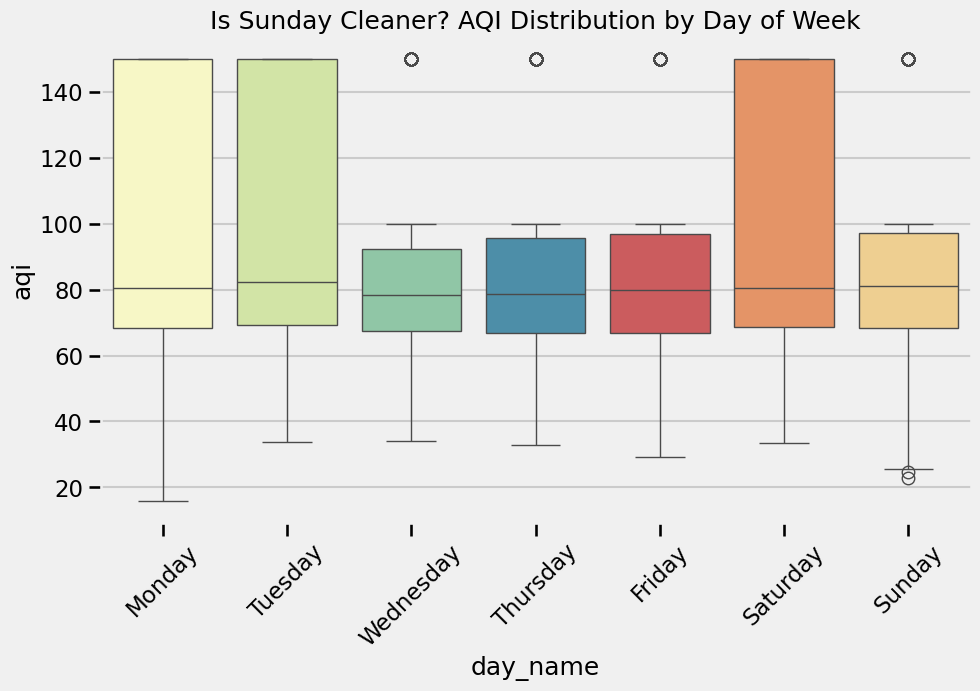

In [5]:
plt.figure(figsize=(10, 6))

# Map weekday numbers to names
df['day_name'] = df['datetime'].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Added hue='day_name' and legend=False to remove the FutureWarning
sns.boxplot(
    x='day_name', 
    y='aqi', 
    data=df, 
    order=day_order, 
    palette="Spectral", 
    hue='day_name', 
    legend=False
)

plt.title("Is Sunday Cleaner? AQI Distribution by Day of Week", fontsize=18)
plt.xticks(rotation=45)
plt.show()

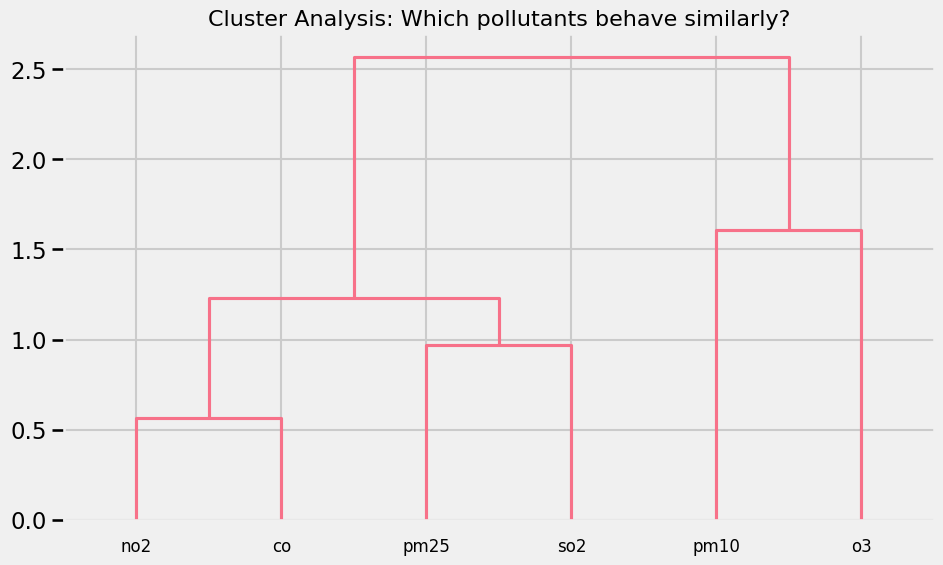

In [6]:
from scipy.cluster import hierarchy

corr = df[['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']].corr()
linkage = hierarchy.linkage(corr, method='ward')

plt.figure(figsize=(10, 6))
hierarchy.dendrogram(linkage, labels=corr.columns, color_threshold=0)
plt.title("Cluster Analysis: Which pollutants behave similarly?", fontsize=16)
plt.show()

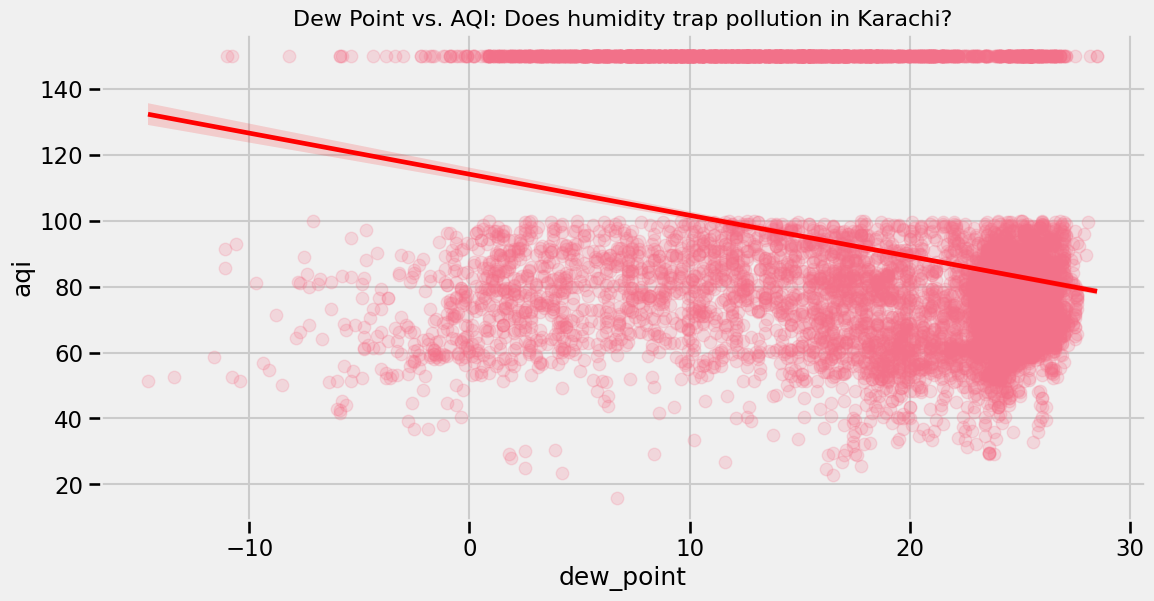

In [7]:
plt.figure(figsize=(12, 6))
sns.regplot(data=df, x='dew_point', y='aqi', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title("Dew Point vs. AQI: Does humidity trap pollution in Karachi?", fontsize=16)
plt.show()

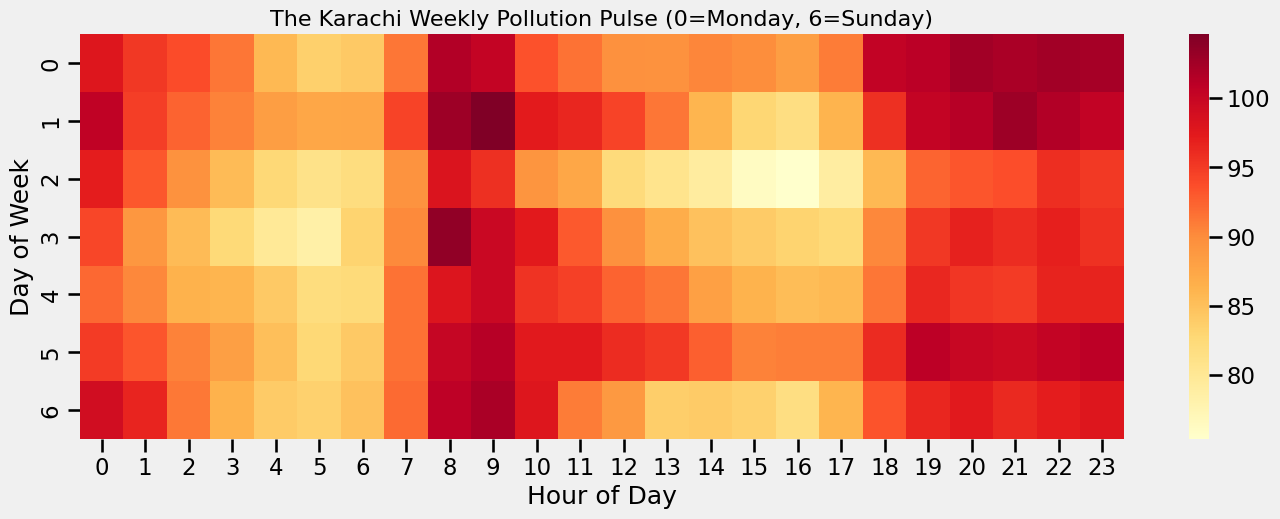

In [8]:
pivot = df.pivot_table(index='weekday', columns='hour', values='aqi', aggfunc='mean')
plt.figure(figsize=(15, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False)
plt.title("The Karachi Weekly Pollution Pulse (0=Monday, 6=Sunday)", fontsize=16)
plt.ylabel("Day of Week")
plt.xlabel("Hour of Day")
plt.show()

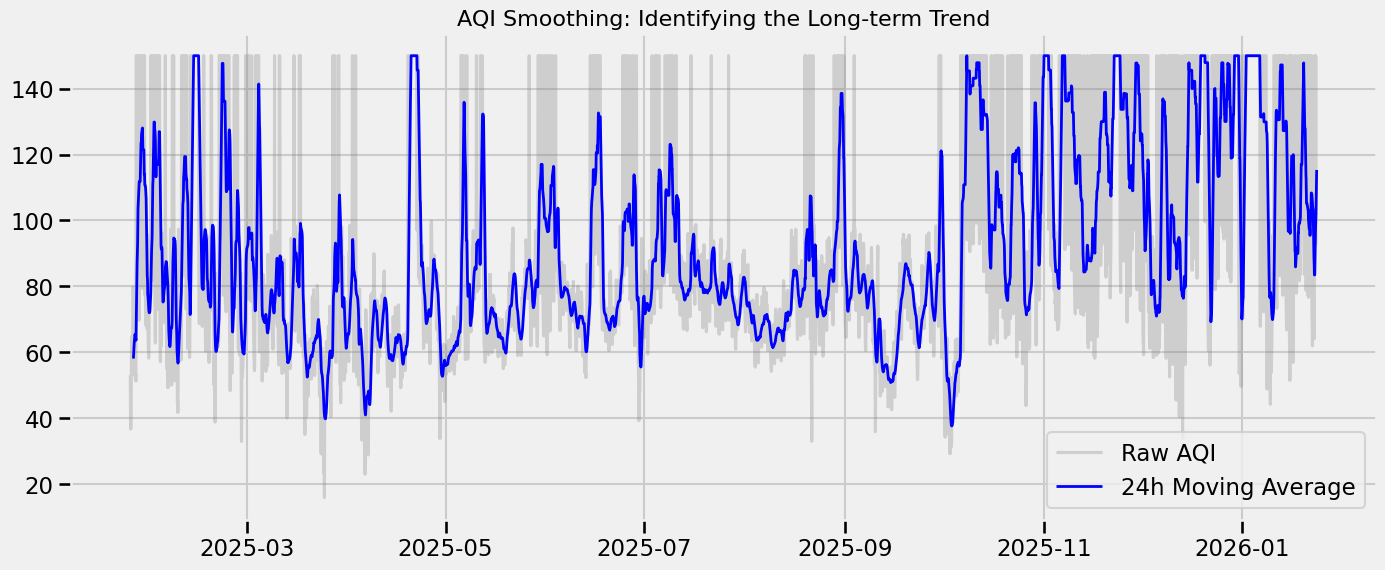

In [9]:
plt.figure(figsize=(15, 6))
plt.plot(df['datetime'], df['aqi'], alpha=0.3, label='Raw AQI', color='gray')
plt.plot(df['datetime'], df['aqi'].rolling(24).mean(), label='24h Moving Average', color='blue', lw=2)
plt.title("AQI Smoothing: Identifying the Long-term Trend", fontsize=16)
plt.legend()
plt.show()

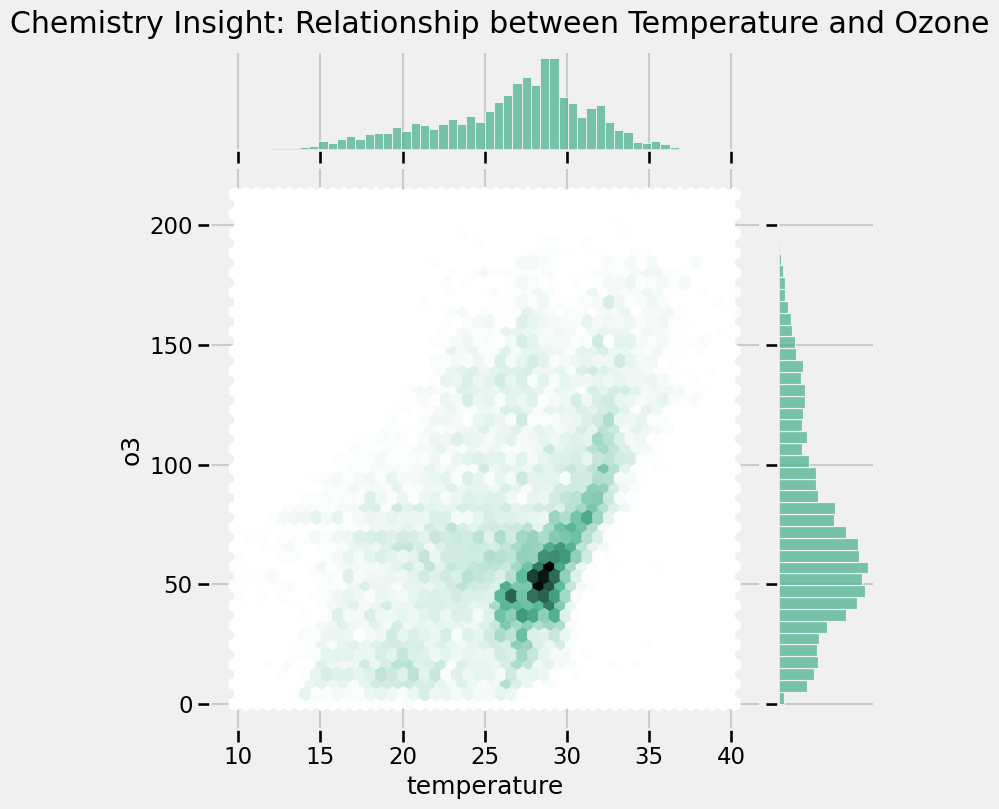

In [10]:
sns.jointplot(data=df, x='temperature', y='o3', kind="hex", color="#4CB391", height=8)
plt.suptitle("Chemistry Insight: Relationship between Temperature and Ozone", y=1.02)
plt.show()

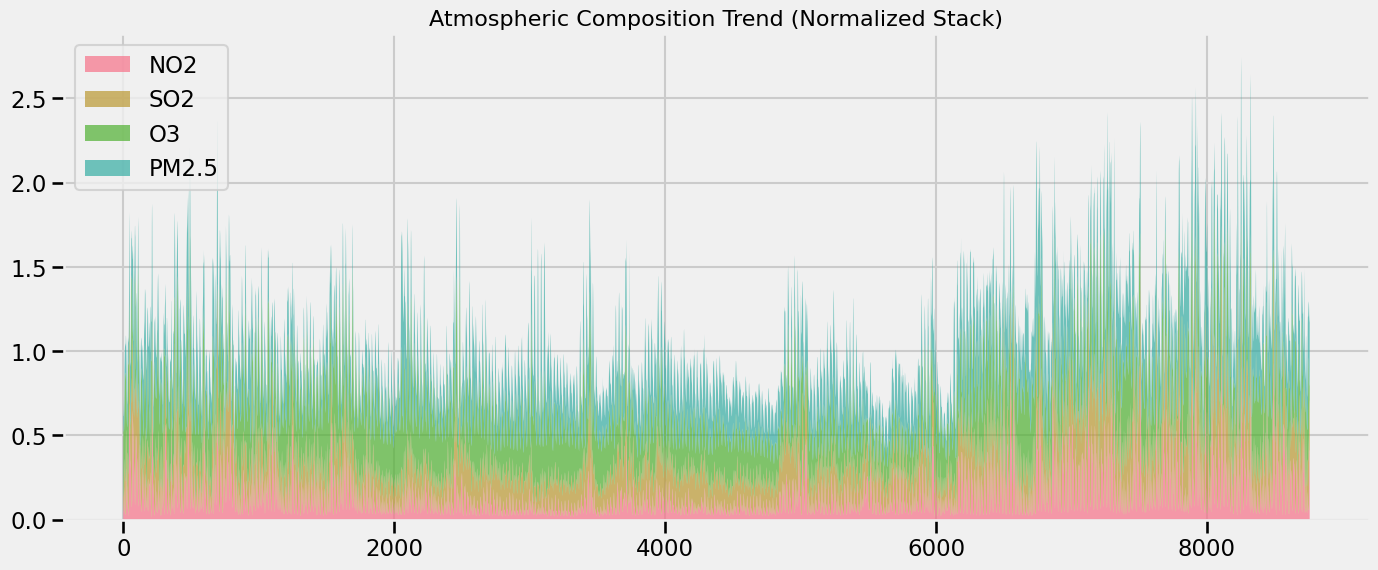

In [11]:
df_norm = df[['no2', 'so2', 'o3', 'pm25']].copy()
df_norm = df_norm.divide(df_norm.max()) # Normalize for comparison

plt.figure(figsize=(15, 6))
plt.stackplot(range(len(df_norm)), df_norm['no2'], df_norm['so2'], df_norm['o3'], df_norm['pm25'], 
              labels=['NO2', 'SO2', 'O3', 'PM2.5'], alpha=0.7)
plt.legend(loc='upper left')
plt.title("Atmospheric Composition Trend (Normalized Stack)", fontsize=16)
plt.show()

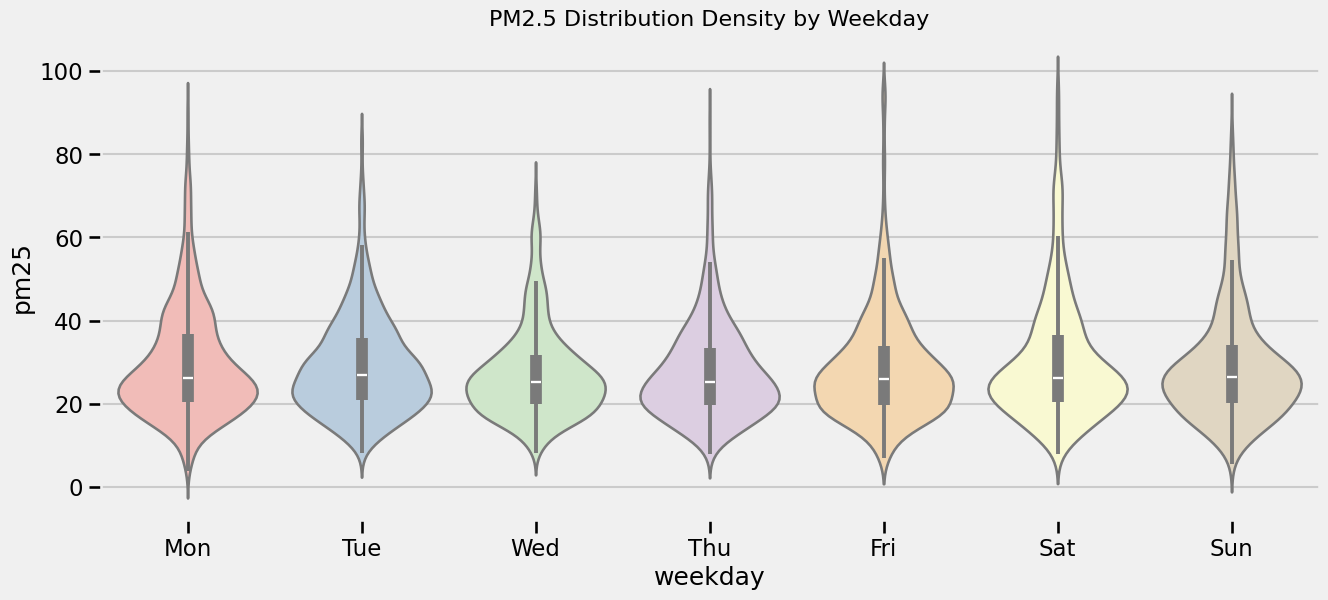

In [13]:
plt.figure(figsize=(14, 6))

# Fixed by explicitly assigning hue and disabling the redundant legend
sns.violinplot(
    x='weekday', 
    y='pm25', 
    data=df, 
    palette="Pastel1", 
    hue='weekday', 
    legend=False
)

plt.title("PM2.5 Distribution Density by Weekday", fontsize=16)
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()

In [14]:
# Select core columns for statistics
stats_cols = ['aqi', 'pm25', 'no2', 'so2', 'temperature', 'humidity', 'wind_speed']

# Calculate Statistics
summary_stats = df[stats_cols].describe().T # Transpose for better readability
summary_stats['skewness'] = df[stats_cols].skew() # Check for outliers/data lean

print("--- KARACHI AIR QUALITY DESCRIPTIVE SUMMARY ---")
display(summary_stats.style.background_gradient(cmap='YlOrRd')) # Makes the table look professional

--- KARACHI AIR QUALITY DESCRIPTIVE SUMMARY ---


,count,mean,std,min,25%,50%,75%,max,skewness
aqi,8760.000000,91.783345,34.082673,15.833333,68.034335,80.021459,97.686695,150.000000,0.848382
pm25,8760.000000,28.890856,12.945239,3.800000,20.200000,25.900000,34.300000,96.400000,1.485229
no2,8760.000000,21.867237,19.557336,1.500000,8.000000,15.100000,29.100000,138.500000,1.816135
so2,8760.000000,16.218436,8.464791,4.900000,10.600000,14.000000,19.300000,65.400000,1.848043
temperature,8760.000000,26.612580,4.705871,9.800000,23.800000,27.500000,29.700000,40.200000,-0.588332
humidity,8760.000000,63.581279,22.077684,5.000000,48.000000,69.000000,82.000000,99.000000,-0.625321
wind_speed,8760.000000,10.655605,4.390820,0.200000,7.500000,10.300000,13.700000,26.800000,0.253534


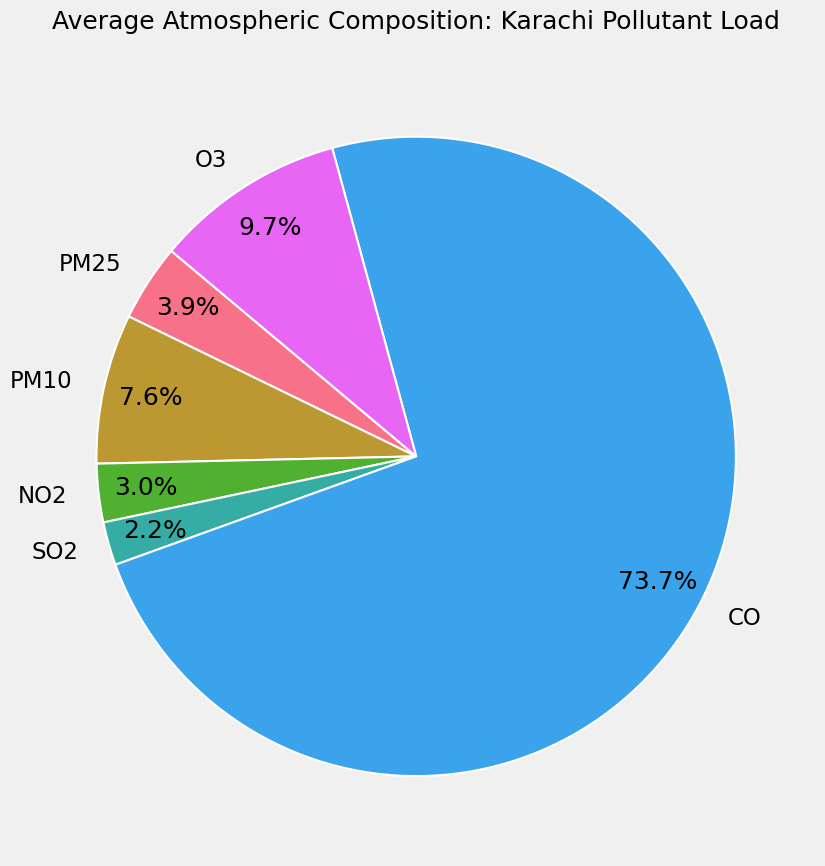

In [16]:
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
pollutant_sums = df[pollutants].mean()

plt.figure(figsize=(12, 9)) # Slightly larger figure for better spacing
plt.pie(
    pollutant_sums, 
    labels=[p.upper() for p in pollutants], 
    autopct='%1.1f%%', 
    colors=sns.color_palette("husl", 6), 
    wedgeprops={'edgecolor':'white', 'linewidth': 1.5},
    startangle=140,      # Rotates the pie to position smaller slices better
    pctdistance=0.85,    # Moves percentage text further from the center
    labeldistance=1.1    # Moves labels slightly further out
)
plt.title("Average Atmospheric Composition: Karachi Pollutant Load", fontsize=18, pad=20)
plt.tight_layout()
plt.show()

--- DAY VS NIGHT POLLUTION STATS ---
             mean    max        std
is_day                             
Day     90.644099  150.0  33.366197
Night   93.129727  150.0  34.866670


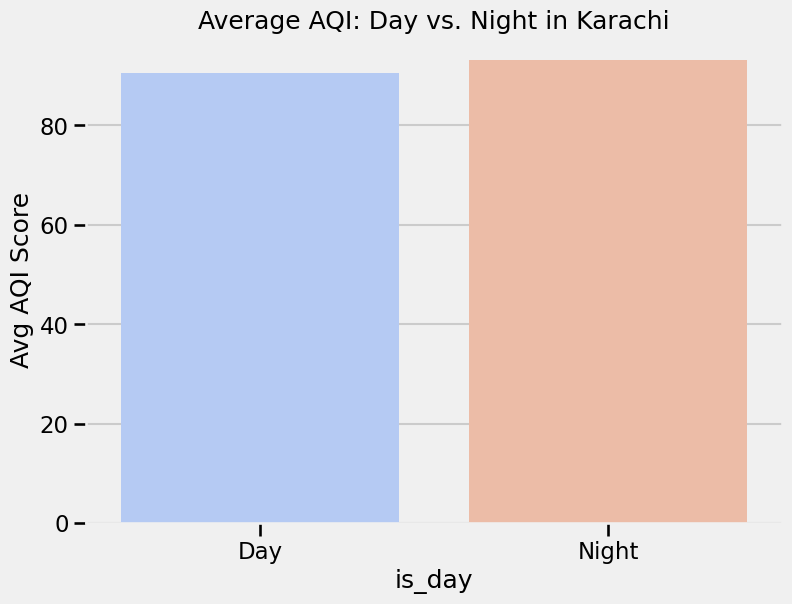

In [18]:
# Create Day/Night feature
df['is_day'] = df['hour'].apply(lambda x: 'Day' if 6 <= x <= 18 else 'Night')

day_night_stats = df.groupby('is_day')['aqi'].agg(['mean', 'max', 'std'])
print("--- DAY VS NIGHT POLLUTION STATS ---")
print(day_night_stats)

# Visualizing the difference
plt.figure(figsize=(8, 6))
sns.barplot(
    x=day_night_stats.index, 
    y=day_night_stats['mean'], 
    palette='coolwarm',
    hue=day_night_stats.index,
    legend=False
)

plt.title("Average AQI: Day vs. Night in Karachi")
plt.ylabel("Avg AQI Score")
plt.show()

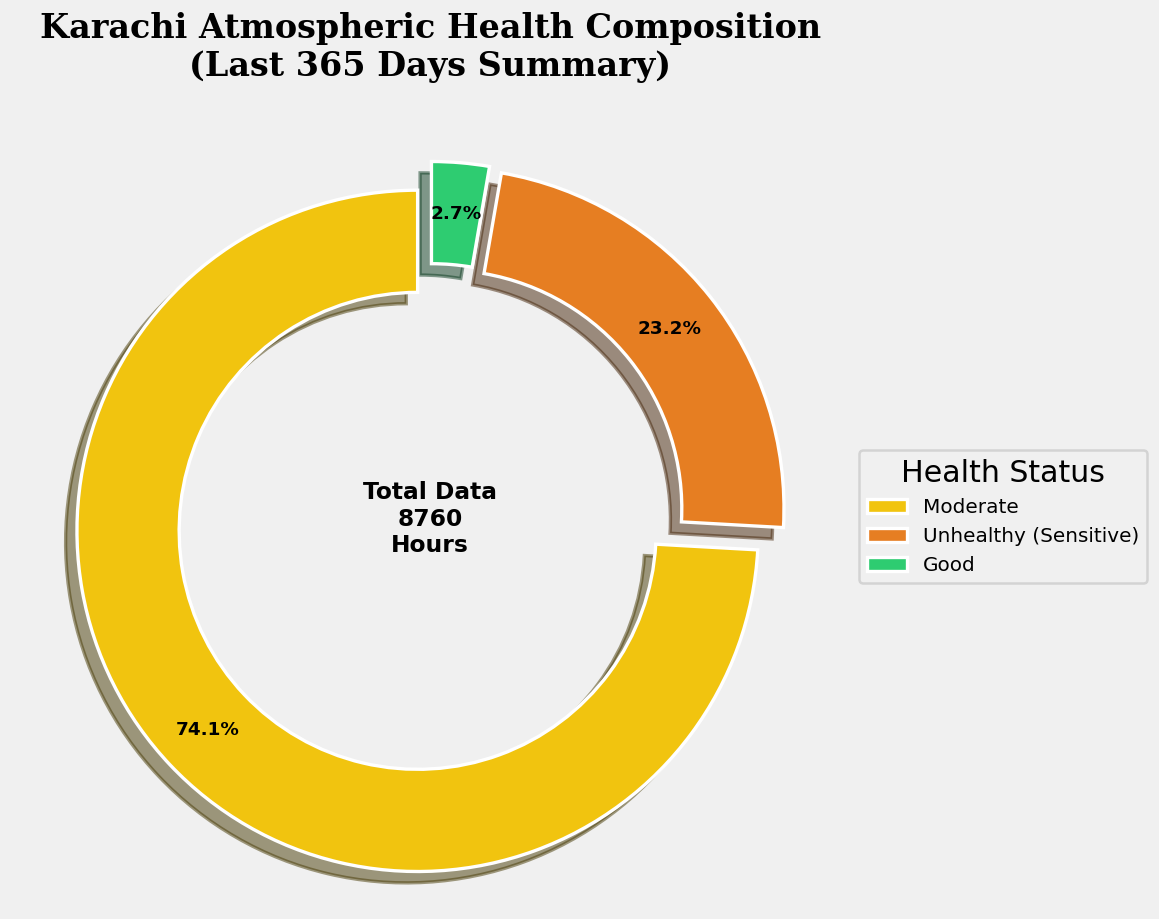

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PREPARE DATA ---
df['aqi'] = pd.to_numeric(df['aqi'], errors='coerce')
temp_df = df.dropna(subset=['aqi']).copy()

def get_label(x):
    if x <= 50: return 'Good'
    elif x <= 100: return 'Moderate'
    elif x <= 150: return 'Unhealthy (Sensitive)'
    else: return 'Hazardous'

temp_df['aqi_status'] = temp_df['aqi'].apply(get_label)
status_counts = temp_df['aqi_status'].value_counts()

# --- 2. DEFINE PROFESSIONAL COLORS ---
# Custom palette matching AQI health standards
color_map = {
    'Good': '#2ecc71',        # Emerald Green
    'Moderate': '#f1c40f',    # Sun Flower Yellow
    'Unhealthy (Sensitive)': '#e67e22', # Carrot Orange
    'Hazardous': '#e74c3c'    # Alizarin Red
}
colors = [color_map.get(label, '#95a5a6') for label in status_counts.index]

# --- 3. HIGH-QUALITY PLOTTING ---
fig, ax = plt.subplots(figsize=(10, 8), dpi=120) # High Resolution

# Create the Donut Chart
wedges, texts, autotexts = ax.pie(
    status_counts, 
    labels=None, # Use legend instead for cleaner look
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors,
    pctdistance=0.85, 
    explode=[0.05] * len(status_counts), # Equal spacing
    shadow=True,
    wedgeprops={'width': 0.3, 'edgecolor': 'white', 'linewidth': 2} # Creating the Donut
)

# Style the percentage text
plt.setp(autotexts, size=11, weight="bold", color="black")

# --- 4. ADD CENTRAL TOTAL INDICATOR ---
total_hours = len(temp_df)
ax.text(0, 0, f'Total Data\n{total_hours}\nHours', ha='center', va='center', 
        fontsize=14, fontweight='bold', family='sans-serif')

# --- 5. ENHANCE LEGEND AND LABELS ---
ax.legend(wedges, status_counts.index, title="Health Status", 
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

plt.title("Karachi Atmospheric Health Composition\n(Last 365 Days Summary)", 
          fontsize=20, fontweight='bold', pad=30, family='serif')

plt.axis('equal') 
plt.tight_layout()
plt.show()

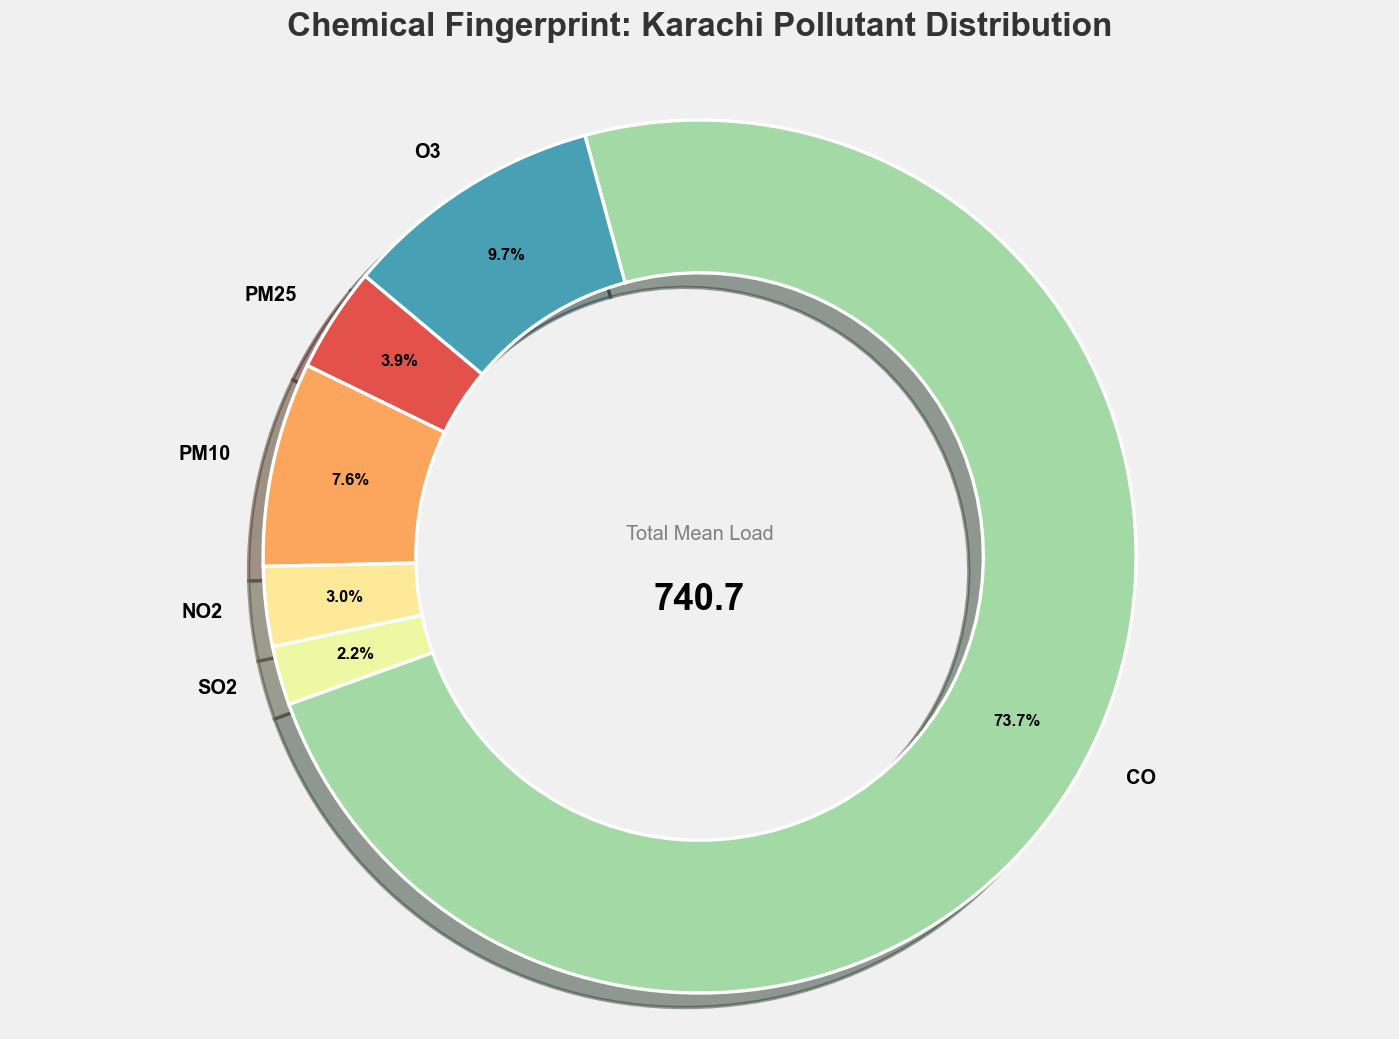

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- PREPARE DATA ---
pollutants_to_plot = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
pollutant_means = df[pollutants_to_plot].mean()
pollutant_means = pollutant_means[pollutant_means > 0]

# --- STYLE SETTINGS ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial'] # Standard professional font
colors = sns.color_palette("Spectral", len(pollutant_means))

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(12, 9), dpi=120)

# Create the main chart
wedges, texts, autotexts = ax.pie(
    pollutant_means, 
    labels=[p.upper() for p in pollutant_means.index],
    autopct='%1.1f%%', 
    pctdistance=0.82,     # Distance from center for percentages
    labeldistance=1.1,    # Distance from center for labels
    startangle=140, 
    colors=colors,
    wedgeprops={'width': 0.35, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    shadow=True
)

# Style percentages (autotexts)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(10)

# Add a central metric (Total mean concentration)
total_mean = pollutant_means.sum()
ax.text(0, 0.05, 'Total Mean Load', ha='center', va='center', fontsize=12, color='gray')
ax.text(0, -0.1, f'{total_mean:.1f}', ha='center', va='center', fontsize=22, fontweight='bold')

# --- FINAL POLISHING ---
plt.title("Chemical Fingerprint: Karachi Pollutant Distribution", 
          fontsize=20, fontweight='bold', pad=30, color='#333333')

# Remove repetitive legend as labels are direct
# plt.legend() is redundant here

plt.axis('equal') 
plt.tight_layout()
plt.show()